# Dataset Setup

In [1]:
from google.colab import drive
import os
import shutil
import kagglehub

# Google Drive
drive.mount('/content/drive')

# Download dataset from Kaggle
print("Downloading dataset from Kaggle...")
os.environ["KAGGLEHUB_VERIFY_SSL"] = "0"
temp_path = kagglehub.dataset_download("andrewmvd/medical-mnist")
print("Downloaded to temporary path:", temp_path)

# Define the destination path in Google Drive
DRIVE_DATA_DIR = '/content/drive/MyDrive/medical-mnist'

# Upload/Move dataset to Google Drive if it doesn't exist
if not os.path.exists(DRIVE_DATA_DIR):
    print(f"Moving dataset to Google Drive: {DRIVE_DATA_DIR}...")
    shutil.copytree(temp_path, DRIVE_DATA_DIR)
    print("Dataset successfully uploaded to Google Drive.")
else:
    print(f"Dataset already exists in Google Drive at {DRIVE_DATA_DIR}.")

!pip install tensorflow matplotlib numpy seaborn scikit-learn

Mounted at /content/drive
Using Colab cache for faster access to the 'medical-mnist' dataset.
Downloaded to temporary path: /kaggle/input/medical-mnist
Moving dataset to Google Drive: /content/drive/MyDrive/medical-mnist...
Dataset successfully uploaded to Google Drive.


In [2]:
import kagglehub

#Path to your zip file
zip_path = "/content/drive/MyDrive/A1 data/archive (20).zip"

#Unzip dataset
import zipfile
import os

extract_path = "/content/medical_mnist"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

#Final dataset path (USE THIS)
path = extract_path

print("Dataset extracted to:", path)
print("Folders:", os.listdir(path)[:10])

Dataset extracted to: /content/medical_mnist
Folders: ['HeadCT', 'BreastMRI', 'ChestCT', 'AbdomenCT', 'CXR', 'Hand']


In [3]:
#Convert dataset → TensorFlow pipeline
import tensorflow as tf
import os

IMG_SIZE = 64
BATCH_SIZE = 32

def create_dataset(data_dir):
    files = tf.data.Dataset.list_files(data_dir + "/*/*.jpeg", shuffle=True)

    def load_image(file_path):
        img = tf.io.read_file(file_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (64, 64))
        img = tf.cast(img, tf.float32) / 255.0
        return img

    def make_pair(file_path):
        img = load_image(file_path)
        return (img, img)   #fix to ur be tuple

    dataset = files.map(make_pair, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(32)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [4]:
ds = create_dataset(path)
print(ds.element_spec)

(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None))


In [5]:
for x, y in ds.take(1):
    print(x.shape, y.shape)

(32, 64, 64, 3) (32, 64, 64, 3)


# AE

In [94]:
from tensorflow.keras import layers, Model

LATENT_DIM = 16

# Encoder
x = layers.Conv2D(32, 3, activation='relu', strides=2, padding='same')(encoder_inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, 3, activation='relu', strides=2, padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, 3, activation='relu', strides=2, padding='same')(x)
x = layers.Flatten()(x)
latent = layers.Dense(LATENT_DIM, activation='relu')(x)

# Decoder
x = layers.Dense(8*8*128, activation='relu')(latent)
x = layers.Reshape((8,8,128))(x)
x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)
outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

autoencoder = Model(encoder_inputs, outputs)
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),loss='mse')

In [95]:
history_ae = autoencoder.fit(ds,epochs=20,verbose=1)

Epoch 1/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 57s 27ms/step - loss: 0.0142
Epoch 2/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - loss: 0.0100
Epoch 3/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0091
Epoch 4/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0085
Epoch 5/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0082
Epoch 6/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0079
Epoch 7/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0077
Epoch 8/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0075
Epoch 9/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0074
Epoch 10/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - loss: 0.0073
Epoch 11/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0071
Epoch 12/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - loss: 0.0071
Epoch 13/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - loss: 0.0070
Epoch 14/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0069
E

# VAE

In [97]:
import tensorflow as tf
from tensorflow.keras import layers, Model
latent_dim = 4

#ENCODER
inputs = layers.Input(shape=(64, 64, 3))
x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Flatten()(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# reparameterization trick
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])
encoder = Model(inputs, [z_mean, z_log_var, z], name="encoder")

In [98]:
#decoder
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(8 * 8 * 128, activation='relu')(latent_inputs)
x = layers.Reshape((8, 8, 128))(x)
x = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu')(x)

outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)
decoder = Model(latent_inputs, outputs, name="decoder")

In [99]:
#VAE MODEL
class VAE(Model):
    def __init__(self, encoder, decoder):
        super(VAE, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        outputs = self.decoder(z)

        # Reconstruction loss
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(inputs - outputs), axis=(1,2,3)))

        # KL divergence loss
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1))

        # KL weighting (for good images)
        kl_weight = 0.3

        self.add_loss(reconstruction_loss + kl_weight * kl_loss)
        return outputs

In [103]:
# Build + train and loss
import tensorflow as tf
from tensorflow.keras import Model

vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))

In [104]:
history = vae.fit(ds, epochs=20)

Epoch 1/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 55s 26ms/step - loss: 145.6264
Epoch 2/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 144.4144
Epoch 3/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - loss: 143.8418
Epoch 4/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 143.3146
Epoch 5/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - loss: 142.8670
Epoch 6/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 24ms/step - loss: 142.4397
Epoch 7/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 142.0452
Epoch 8/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - loss: 141.7100
Epoch 9/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 141.3435
Epoch 10/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 140.9980
Epoch 11/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - loss: 140.6800
Epoch 12/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 140.3799
Epoch 13/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - loss: 140.0689
Epoch 14/20
1843/1843 ━━━━━━━━━━━━━━━━━━━━ 46s 

# Visualizations

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step


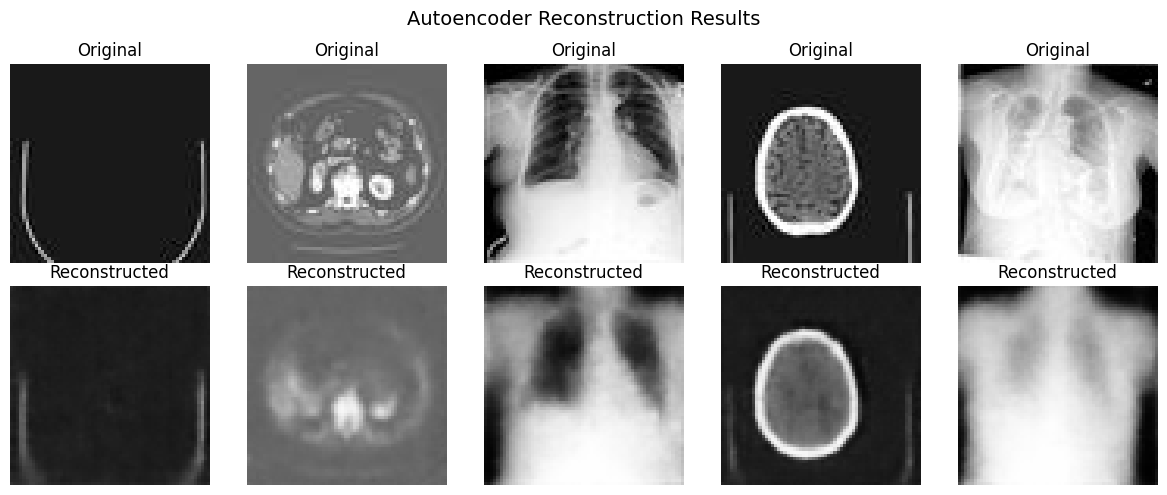

In [105]:
#Reconstruction
import matplotlib.pyplot as plt
import numpy as np

for batch in ds.take(1):
    x, y = batch
    recon = autoencoder.predict(x)

plt.figure(figsize=(12,5))
n = 5
for i in range(n):
    # original
    plt.subplot(2, n, i+1)
    plt.imshow(x[i])
    plt.title("Original")
    plt.axis("off")
    # reconstruction
    plt.subplot(2, n, i+n+1)
    plt.imshow(recon[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle("Autoencoder Reconstruction Results", fontsize=14)
plt.tight_layout()
plt.show()

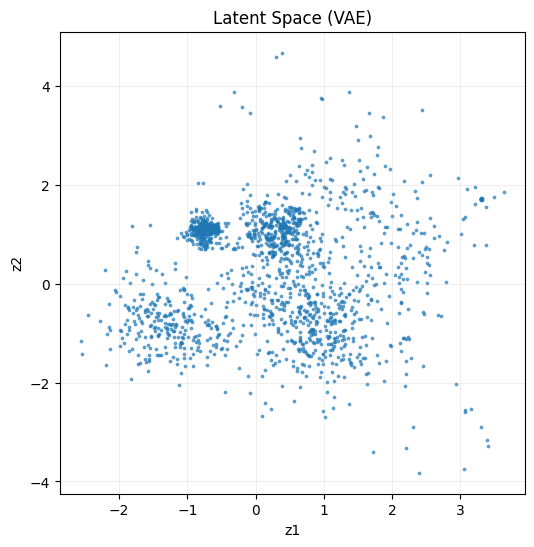

In [106]:
#Latent space
import numpy as np
import matplotlib.pyplot as plt

z_means = []
for batch in ds.take(50):
    x, y = batch
    z_mean_vals, _, _ = encoder.predict(x, verbose=0)
    z_means.append(z_mean_vals)

z_means = np.concatenate(z_means)

plt.figure(figsize=(6,6))
plt.scatter(z_means[:,0], z_means[:,1], s=3, alpha=0.6)
plt.title("Latent Space (VAE)")
plt.xlabel("z1")
plt.ylabel("z2")
plt.grid(True, alpha=0.2)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


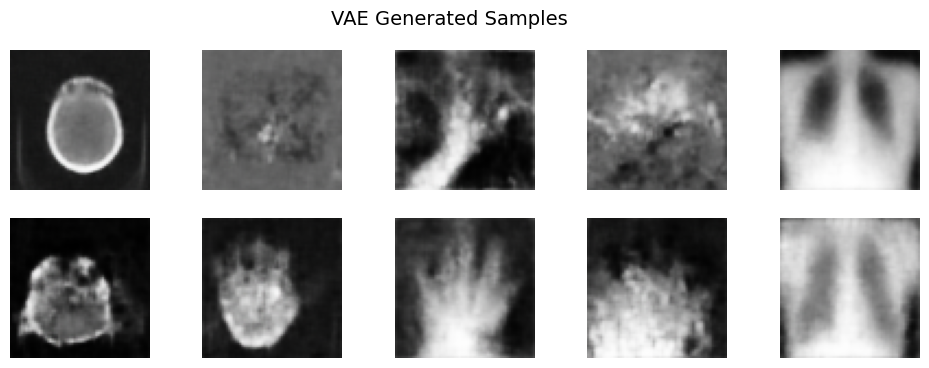

In [110]:
#generate new images (VAE)
import matplotlib.pyplot as plt
import numpy as np

# random samples
z = np.random.normal(0, 1, (10, latent_dim))
generated = decoder.predict(z)
plt.figure(figsize=(12,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(generated[i])
    plt.axis('off')

plt.suptitle("VAE Generated Samples", fontsize=14)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 622ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


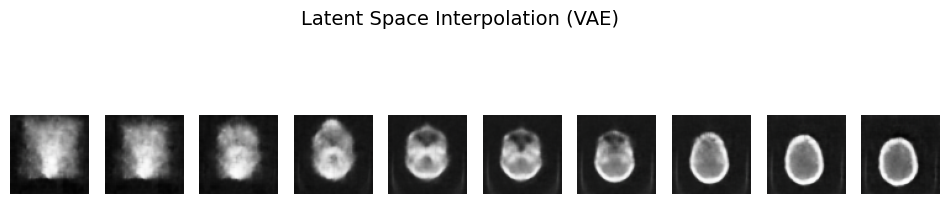

In [108]:
z1 = np.random.normal(0,1,(1,latent_dim))
z2 = np.random.normal(0,1,(1,latent_dim))

plt.figure(figsize=(12,3))

for i, t in enumerate(np.linspace(0,1,10)):
    z = (1-t)*z1 + t*z2
    img = decoder.predict(z)

    plt.subplot(1,10,i+1)
    plt.imshow(img[0])
    plt.axis("off")

plt.suptitle("Latent Space Interpolation (VAE)", fontsize=14)
plt.show()

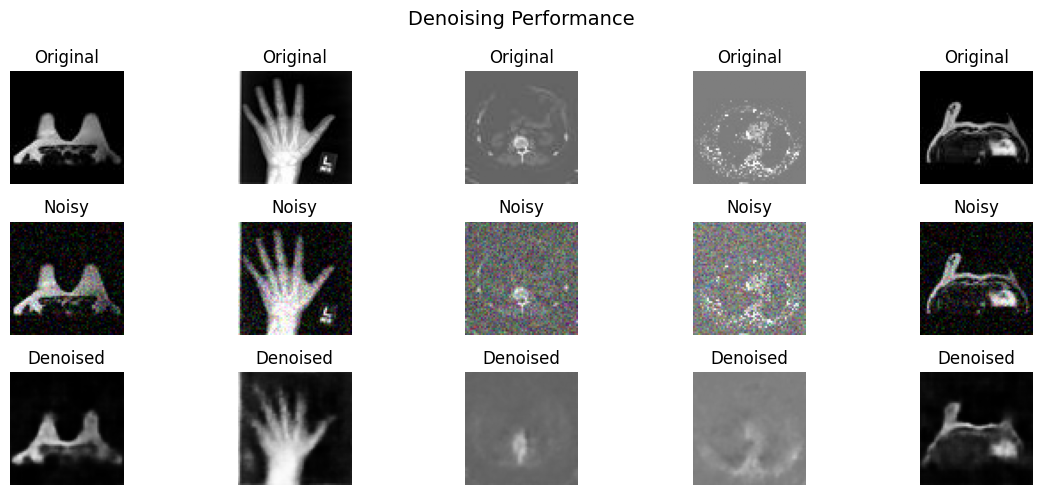

In [109]:
#denoising
import tensorflow as tf
import matplotlib.pyplot as plt

for batch in ds.take(1):
    x, y = batch
    noise = tf.random.normal(shape=tf.shape(x), stddev=0.1)
    noisy = x + noise
    noisy = tf.clip_by_value(noisy, 0.0, 1.0)
    denoised = autoencoder(noisy, training=False)
plt.figure(figsize=(12,5))

n = 5
for i in range(n):
    # original
    plt.subplot(3, n, i+1)
    plt.imshow(x[i])
    plt.title("Original")
    plt.axis("off")
    # noisy
    plt.subplot(3, n, i+n+1)
    plt.imshow(noisy[i])
    plt.title("Noisy")
    plt.axis("off")
    # denoised
    plt.subplot(3, n, i+2*n+1)
    plt.imshow(denoised[i])
    plt.title("Denoised")
    plt.axis("off")

plt.suptitle("Denoising Performance", fontsize=14)
plt.tight_layout()
plt.show()